<a href="https://colab.research.google.com/github/datadigger01/AppStatMat/blob/main/tr_ramen_trend_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 한글폰트 설치

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
plt.rc('font', family='NanumBarunGothic')

In [ ]:
# 파일 경로
#file_path = '/content/drive/MyDrive/AI와무역투자론/Data/trade_ramen_2015_2025.csv'
# 첫 번째 행을 컬럼명으로 사용하여 CSV 읽기
#df = pd.read_csv(file_path, header=0)

df = pd.read_csv('/content/drive/MyDrive/AI와무역투자론/Data/trade_ramen_2015_2025.csv', header=0)
df['year'] = pd.to_datetime(df['year'], format='%Y-%m-%d')

# 데이터 크기와 컬럼명 출력
print("데이터 크기:", df.shape)
print("컬럼명:", df.columns.tolist())
df.info()

데이터 크기: (10718, 10)
컬럼명: ['year', 'balPayments', 'expDlr', 'expWgt', 'hsCd', 'impDlr', 'impWgt', 'statCd', 'statCdCntnKor1', 'statKor']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10718 entries, 0 to 10717
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   year            10707 non-null  datetime64[ns]
 1   balPayments     10718 non-null  int64         
 2   expDlr          10718 non-null  int64         
 3   expWgt          10718 non-null  int64         
 4   hsCd            10718 non-null  object        
 5   impDlr          10718 non-null  int64         
 6   impWgt          10718 non-null  int64         
 7   statCd          10712 non-null  object        
 8   statCdCntnKor1  10718 non-null  object        
 9   statKor         10718 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(4)
memory usage: 837.5+ KB


In [ ]:
# 'year' 컬럼 NaN 값 제거
df = df.dropna(subset=['year'])

# 'year' → datetime 변환 후 연도만 추출
df['year'] = df['year'].dt.year

# groupby 및 집계
agg_df = df.groupby(['year', 'statCd']).agg({
    'balPayments': 'sum',
    'expDlr': 'sum',
    'expWgt': 'sum',
    'impDlr': 'sum',
    'impWgt': 'sum',
    'statCdCntnKor1': 'max',  # 또는 'min'
    'statKor': 'max'          # 또는 'min'
}).reset_index()

agg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1454 entries, 0 to 1453
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   year            1454 non-null   int32 
 1   statCd          1454 non-null   object
 2   balPayments     1454 non-null   int64 
 3   expDlr          1454 non-null   int64 
 4   expWgt          1454 non-null   int64 
 5   impDlr          1454 non-null   int64 
 6   impWgt          1454 non-null   int64 
 7   statCdCntnKor1  1454 non-null   object
 8   statKor         1454 non-null   object
dtypes: int32(1), int64(5), object(3)
memory usage: 96.7+ KB


In [ ]:
pd.options.display.float_format = '{:.5f}'.format
print(agg_df[agg_df['year']==2019].expWgt.describe())

count        133.00000
mean     1032214.96241
std      4045925.30997
min            2.00000
25%         4309.00000
50%        36710.00000
75%       222008.00000
max     41537857.00000
Name: expWgt, dtype: float64


In [ ]:
#df.groupby('year')['expWgt'].median()
# 2019년 데이터 중 expWgt >= median 조건 필터링
df_filtered = agg_df[(agg_df['year'] == 2019) & (agg_df['expWgt'] >= 37000)]

# 해당 국가 목록 추출
countries = df_filtered['statCd'].unique()
#countries

df_target = agg_df[agg_df['statCd'].isin(countries)]
df_target

,year,statCd,balPayments,expDlr,expWgt,impDlr,impWgt,statCdCntnKor1,statKor
0,2015,AE,1470020,1470020,275212,0,0,아랍에미리트 연합,라면
3,2015,AR,513384,513384,128065,0,0,아르헨티나,라면
4,2015,AS,1111541,1111541,196202,0,0,아메리칸 사모아,라면
5,2015,AT,3863,3863,992,0,0,오스트리아,라면
6,2015,AU,11773727,11774071,3066170,344,34,호주,라면
...,...,...,...,...,...,...,...,...,...
1446,2025,US,155145670,155167818,30504467,22148,1116,미국,라면
1448,2025,UZ,3561446,3563195,873986,1749,773,우즈베키스탄,라면
1449,2025,VN,10525008,11960794,3259619,1435786,281983,베트남,라면
1451,2025,WS,920738,920738,185588,0,0,사모아,라면


In [ ]:
# 파일 경로
#file_path = '/content/drive/MyDrive/AI와무역투자론/Data/tr_ramen_10yr_targeted.csv'
# 첫 번째 행을 컬럼명으로 사용하여 CSV 읽기
#df = pd.read_csv(file_path, header=0)

In [ ]:
# 2) Country baseline: total expWgt in 2019 per country
baseline_2019 = (
    df_target.loc[df_target["year"] == 2019, ["statCd", "expWgt"]]
             .groupby("statCd", dropna=False)["expWgt"]
             .sum()
             .rename("expWgt_2019_base") # Renaming the Series directly
)

# 3) Join baseline back
df_target = df_target.join(baseline_2019, on="statCd")
df_target

,year,statCd,balPayments,expDlr,expWgt,impDlr,impWgt,statCdCntnKor1,statKor,expWgt_2019_base
0,2015,AE,1470020,1470020,275212,0,0,아랍에미리트 연합,라면,926442
3,2015,AR,513384,513384,128065,0,0,아르헨티나,라면,159412
4,2015,AS,1111541,1111541,196202,0,0,아메리칸 사모아,라면,214322
5,2015,AT,3863,3863,992,0,0,오스트리아,라면,42017
6,2015,AU,11773727,11774071,3066170,344,34,호주,라면,6147802
...,...,...,...,...,...,...,...,...,...,...
1446,2025,US,155145670,155167818,30504467,22148,1116,미국,라면,14908855
1448,2025,UZ,3561446,3563195,873986,1749,773,우즈베키스탄,라면,89853
1449,2025,VN,10525008,11960794,3259619,1435786,281983,베트남,라면,5669307
1451,2025,WS,920738,920738,185588,0,0,사모아,라면,312968


In [ ]:
df_target['expWgt_ratio']=df_target['expWgt']/df_target['expWgt_2019_base']
df_target

,year,statCd,balPayments,expDlr,expWgt,impDlr,impWgt,statCdCntnKor1,statKor,expWgt_2019_base,expWgt_ratio
0,2015,AE,1470020,1470020,275212,0,0,아랍에미리트 연합,라면,926442,0.29706
3,2015,AR,513384,513384,128065,0,0,아르헨티나,라면,159412,0.80336
4,2015,AS,1111541,1111541,196202,0,0,아메리칸 사모아,라면,214322,0.91545
5,2015,AT,3863,3863,992,0,0,오스트리아,라면,42017,0.02361
6,2015,AU,11773727,11774071,3066170,344,34,호주,라면,6147802,0.49874
...,...,...,...,...,...,...,...,...,...,...,...
1446,2025,US,155145670,155167818,30504467,22148,1116,미국,라면,14908855,2.04606
1448,2025,UZ,3561446,3563195,873986,1749,773,우즈베키스탄,라면,89853,9.72684
1449,2025,VN,10525008,11960794,3259619,1435786,281983,베트남,라면,5669307,0.57496
1451,2025,WS,920738,920738,185588,0,0,사모아,라면,312968,0.59299


In [ ]:
# remove year of 2025
df_target=df_target[df_target['year']!=2025]
df_target

# Transpose 'year' and 'expWgt_ratio' while keeping 'statCd' and 'statCdCntnKor1'
df_transposed = df_target.pivot_table(index=['statCd', 'statCdCntnKor1'], columns='year', values='expWgt_ratio')

# Reset index to turn 'statCd' and 'statCdCntnKor1' back into columns
df_transposed = df_transposed.reset_index()

# Display the transposed DataFrame
df_transposed

year,statCd,statCdCntnKor1,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AE,아랍에미리트 연합,0.29706,0.51491,0.88523,0.84266,1.00000,1.29201,3.07071,4.66942,3.84896,5.26421
1,AR,아르헨티나,0.80336,0.85920,1.13343,0.71478,1.00000,0.44094,0.97789,1.28081,1.31493,1.63544
2,AS,아메리칸 사모아,0.91545,0.89390,0.72354,0.93645,1.00000,1.05042,1.07809,1.33174,1.35045,1.40071
3,AT,오스트리아,0.02361,0.49901,0.54683,0.64005,1.00000,1.97475,2.23583,2.85589,3.56763,2.85077
4,AU,호주,0.49874,0.61946,0.76563,0.91484,1.00000,1.11615,1.01906,1.26689,1.61678,1.96440
...,...,...,...,...,...,...,...,...,...,...,...,...
61,US,미국,0.52257,0.66394,0.78866,0.93340,1.00000,1.46389,1.47368,1.29228,1.82312,2.81045
62,UZ,우즈베키스탄,0.37113,0.44381,0.63368,0.68250,1.00000,1.70125,2.06990,4.14523,5.39264,9.72525
63,VN,베트남,0.16442,0.37042,0.82732,0.71770,1.00000,0.92641,0.88466,0.83176,0.84108,0.98154
64,WS,사모아,0.55037,0.58268,0.63107,0.74645,1.00000,0.82510,1.05434,0.83599,1.20434,0.96186


count   66.00000
mean     2.99956
std      2.44778
min      0.00000
25%      1.41348
50%      2.27298
75%      3.45452
max     11.48814
Name: 2024, dtype: float64


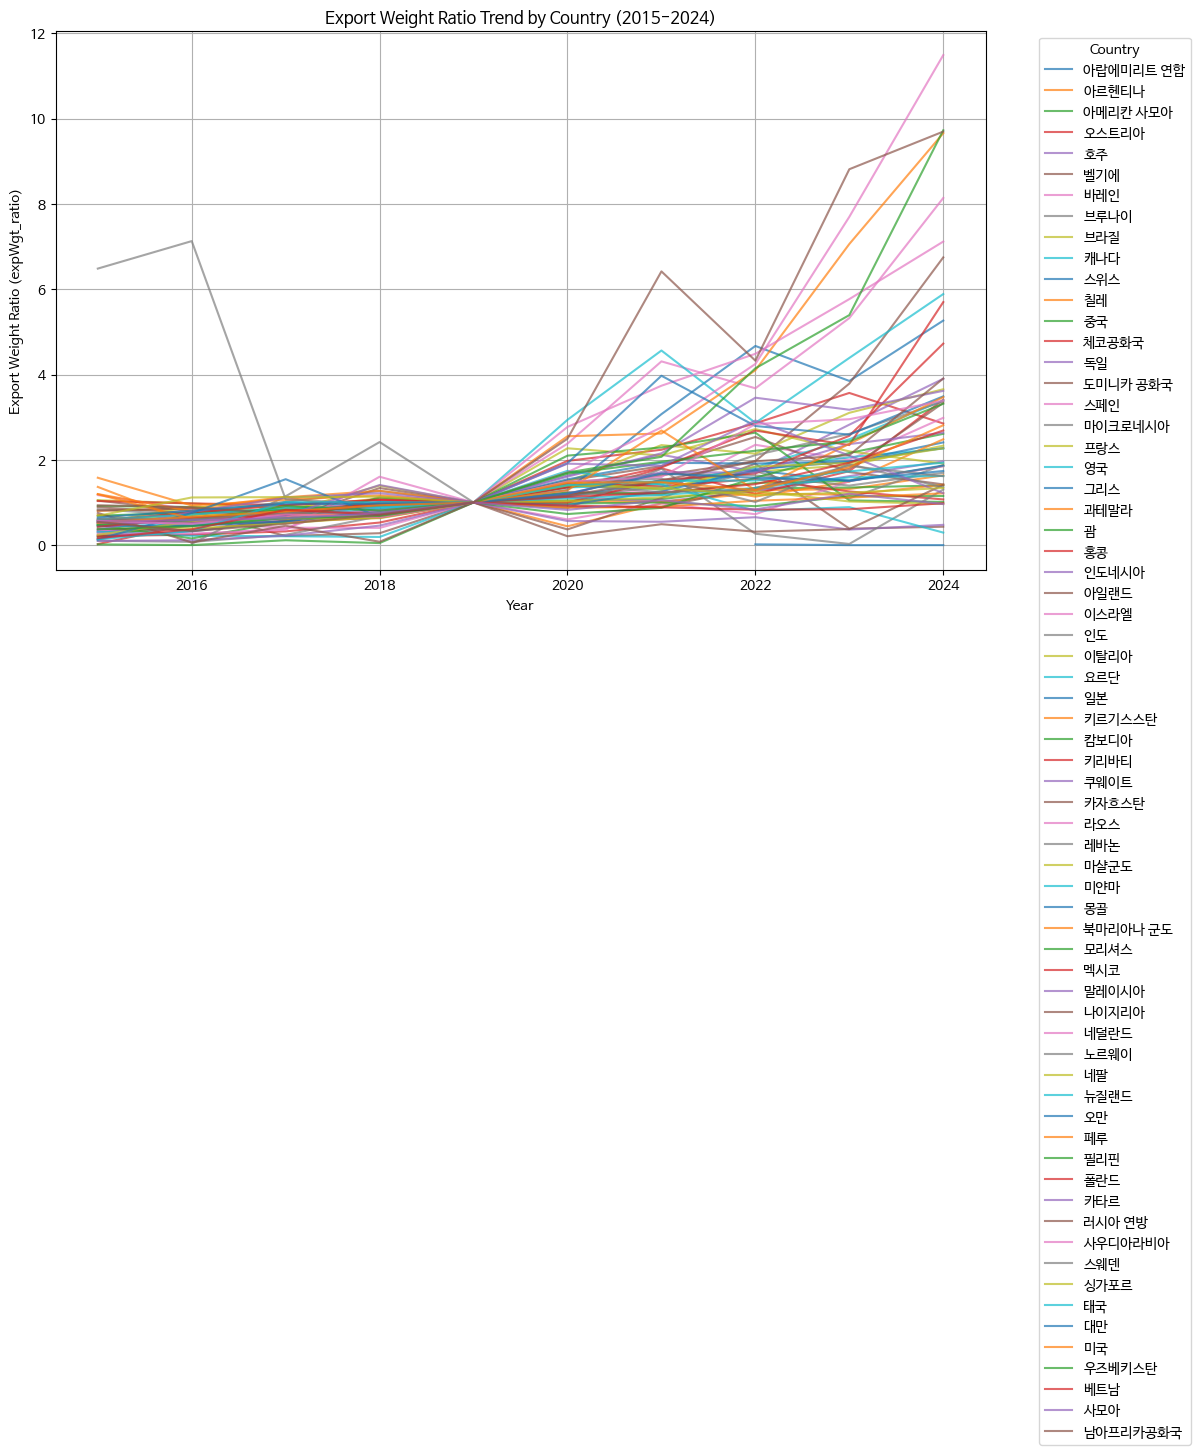

In [ ]:
import matplotlib.pyplot as plt

print(df_transposed[2024].describe())

# Define the columns representing the years
year_columns = [year for year in range(2015, 2025)]

plt.figure(figsize=(12, 7))

# Plot a line for each country
for index, row in df_transposed.iterrows():
    plt.plot(year_columns, row[year_columns], label=row['statCdCntnKor1'], alpha=0.7)

plt.xlabel('Year')
plt.ylabel('Export Weight Ratio (expWgt_ratio)')
plt.title('Export Weight Ratio Trend by Country (2015-2024)')
plt.grid(True)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.tight_layout()
plt.show()

In [ ]:
# Save the df_transposed DataFrame to a CSV file
#output_path = '/content/drive/MyDrive/AI와무역투자론/Data/trade_ramen_clustering.csv'
#df_transposed.to_csv(output_path, index=False, encoding='utf-8-sig')

#print(f"df_transposed DataFrame saved to {output_path}")

## Trend Clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set style for better visualizations
#plt.style.use('seaborn-v0_8-darkgrid')
#sns.set_palette("husl")

In [ ]:
# Prepare data for clustering
# Extract only the year columns (2015-2024) from df_transposed
year_columns = [year for year in range(2015, 2025)] # Use integers as column names are integers

X = df_transposed[year_columns].values
country_names = df_transposed['statCdCntnKor1'].values # Use df_transposed for country names
#print(country_names)

# Handle missing values if any (fill with mean)
X = np.nan_to_num(X, nan=np.nanmean(X)) # Use np.nanmean to calculate mean while ignoring NaNs

In [ ]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

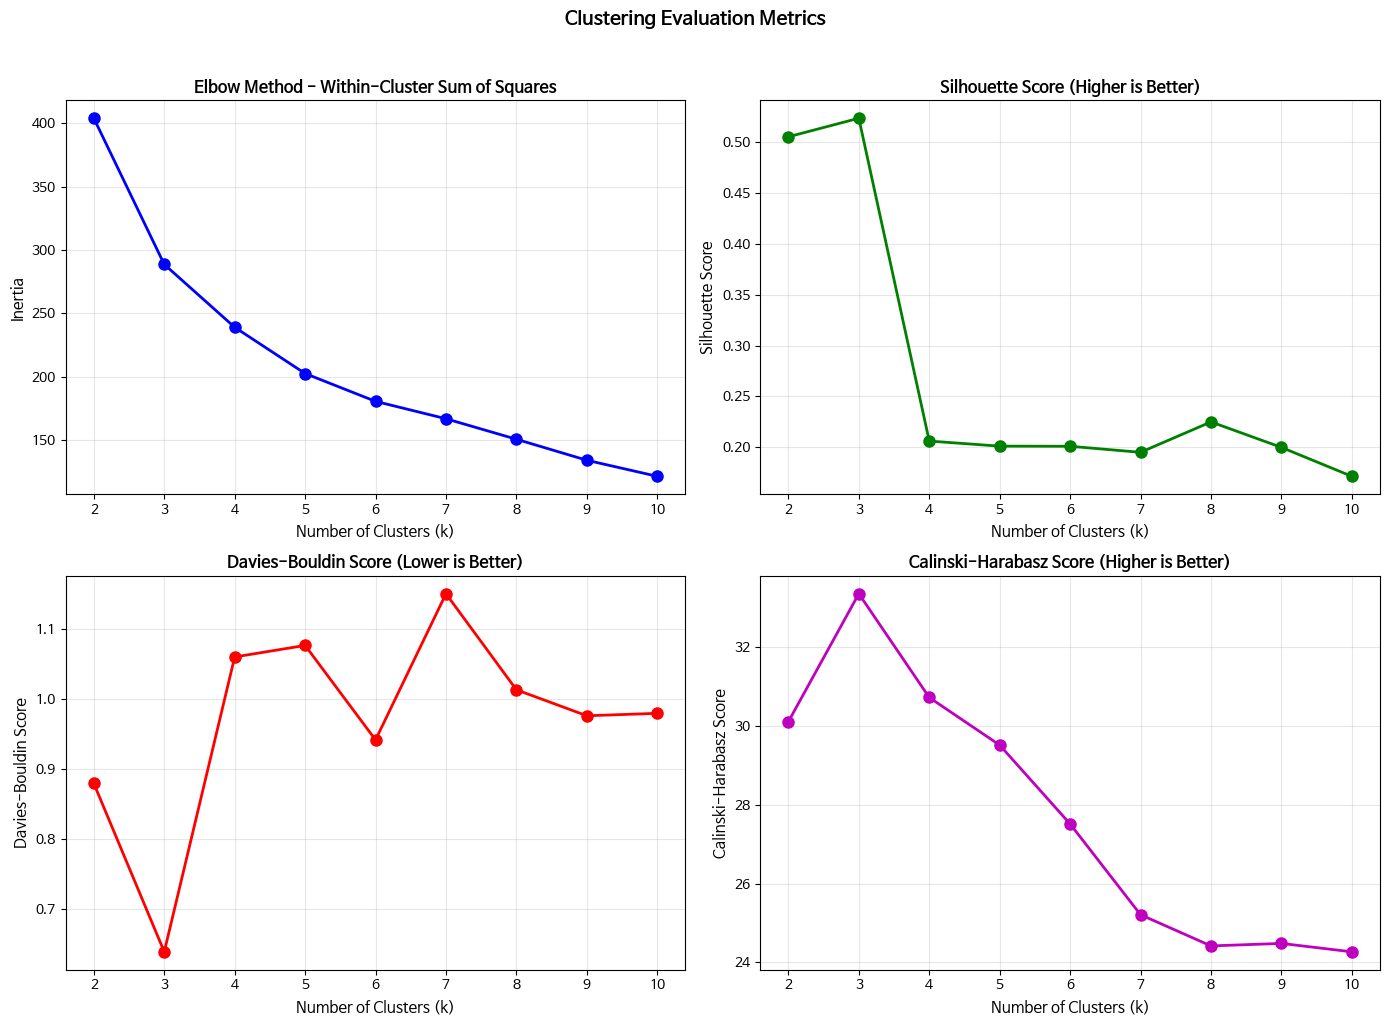

In [ ]:
# Elbow Method
inertias = []
silhouette_scores = []
db_scores = []
ch_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    db_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))
    ch_scores.append(calinski_harabasz_score(X_scaled, kmeans.labels_))

# Plot clustering metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Elbow plot
axes[0, 0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0, 0].set_ylabel('Inertia', fontsize=11)
axes[0, 0].set_title('Elbow Method - Within-Cluster Sum of Squares', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette score
axes[0, 1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 1].set_title('Silhouette Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Davies-Bouldin score
axes[1, 0].plot(K_range, db_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1, 0].set_ylabel('Davies-Bouldin Score', fontsize=11)
axes[1, 0].set_title('Davies-Bouldin Score (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Calinski-Harabasz score
axes[1, 1].plot(K_range, ch_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1, 1].set_ylabel('Calinski-Harabasz Score', fontsize=11)
axes[1, 1].set_title('Calinski-Harabasz Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Clustering Evaluation Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Print scores
print("\nClustering Evaluation Scores:")
print("-"*60)
print(f"{'k':<5} {'Silhouette':<12} {'Davies-Bouldin':<15} {'Calinski-Harabasz':<18}")
print("-"*60)
for i, k in enumerate(K_range):
    print(f"{k:<5} {silhouette_scores[i]:<12.4f} {db_scores[i]:<15.4f} {ch_scores[i]:<18.2f}")

# Determine optimal k (using silhouette score)
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters based on Silhouette Score: {optimal_k}")


Clustering Evaluation Scores:
------------------------------------------------------------
k     Silhouette   Davies-Bouldin  Calinski-Harabasz 
------------------------------------------------------------
2     0.5050       0.8796          30.10             
3     0.5232       0.6392          33.34             
4     0.2062       1.0603          30.71             
5     0.2012       1.0768          29.51             
6     0.2011       0.9418          27.51             
7     0.1952       1.1506          25.21             
8     0.2250       1.0134          24.42             
9     0.2000       0.9763          24.48             
10    0.1716       0.9798          24.27             

Optimal number of clusters based on Silhouette Score: 3


In [ ]:
# Perform K-means with optimal k
#kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df_transposed['cluster'] = clusters


PCA explained variance ratio: [0.45164577 0.24078794]
Total variance explained: 69.24%


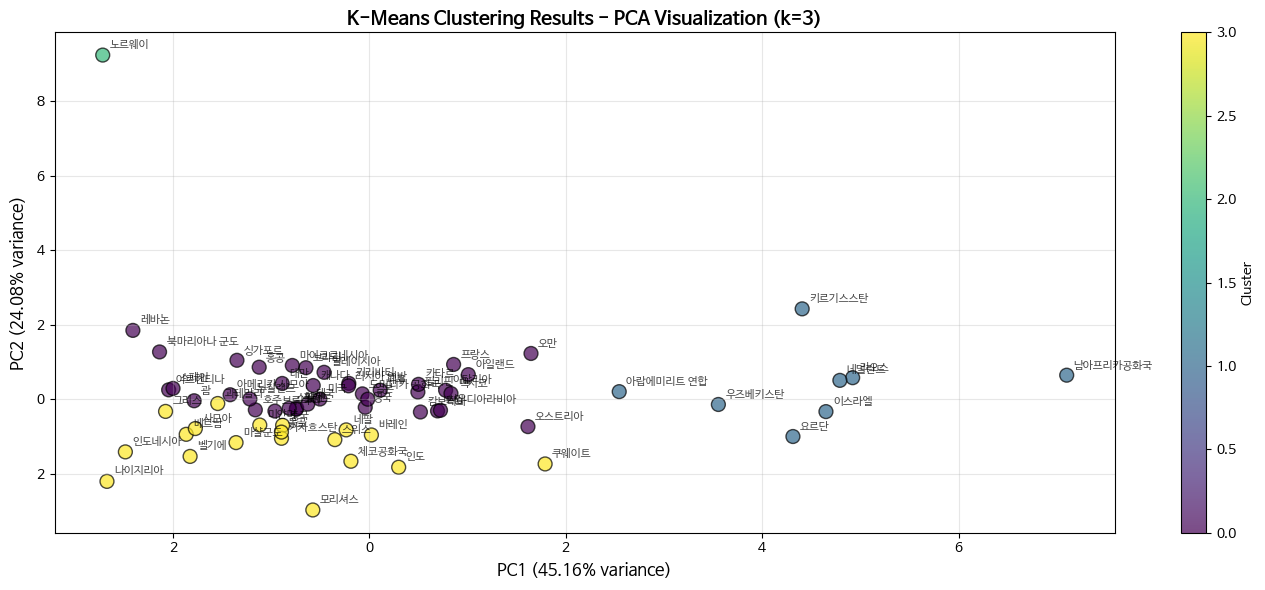

In [ ]:
# ============================================================
# 3. PCA VISUALIZATION
# ============================================================

# Perform PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# Plot PCA visualization
plt.figure(figsize=(14, 6))

# Create scatter plot
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis',
                     s=100, alpha=0.7, edgecolors='black', linewidth=1)

# Add country labels
for i, country in enumerate(country_names):
    plt.annotate(country, (X_pca[i, 0], X_pca[i, 1]),
                fontsize=8, alpha=0.7,
                xytext=(5, 5), textcoords='offset points')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title(f'K-Means Clustering Results - PCA Visualization (k={optimal_k})', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


CLUSTER CHARACTERISTICS

CLUSTER 0 (38 countries)
Countries: 아르헨티나, 아메리칸 사모아, 오스트리아, 호주, 브루나이, 브라질, 캐나다, 칠레, 독일, 도미니카 공화국
          ... and 28 more

Statistics (in tons):
  Average 2024 export: 2
  Total 2024 export: 95
  Average growth (2015-2024): 279.0%

CLUSTER 1 (8 countries)
Countries: 아랍에미리트 연합, 이스라엘, 요르단, 키르기스스탄, 라오스, 네덜란드, 우즈베키스탄, 남아프리카공화국

Statistics (in tons):
  Average 2024 export: 8
  Total 2024 export: 67
  Average growth (2015-2024): 1625.1%

CLUSTER 2 (1 countries)
Countries: 노르웨이

Statistics (in tons):
  Average 2024 export: 1
  Total 2024 export: 1
  Average growth (2015-2024): -79.2%

CLUSTER 3 (19 countries)
Countries: 벨기에, 바레인, 스위스, 중국, 체코공화국, 그리스, 과테말라, 인도네시아, 인도, 쿠웨이트
          ... and 9 more

Statistics (in tons):
  Average 2024 export: 2
  Total 2024 export: 35
  Average growth (2015-2024): 354.1%
Y-axis range fixed to: [-0.0, 0.0] (1000 tons)


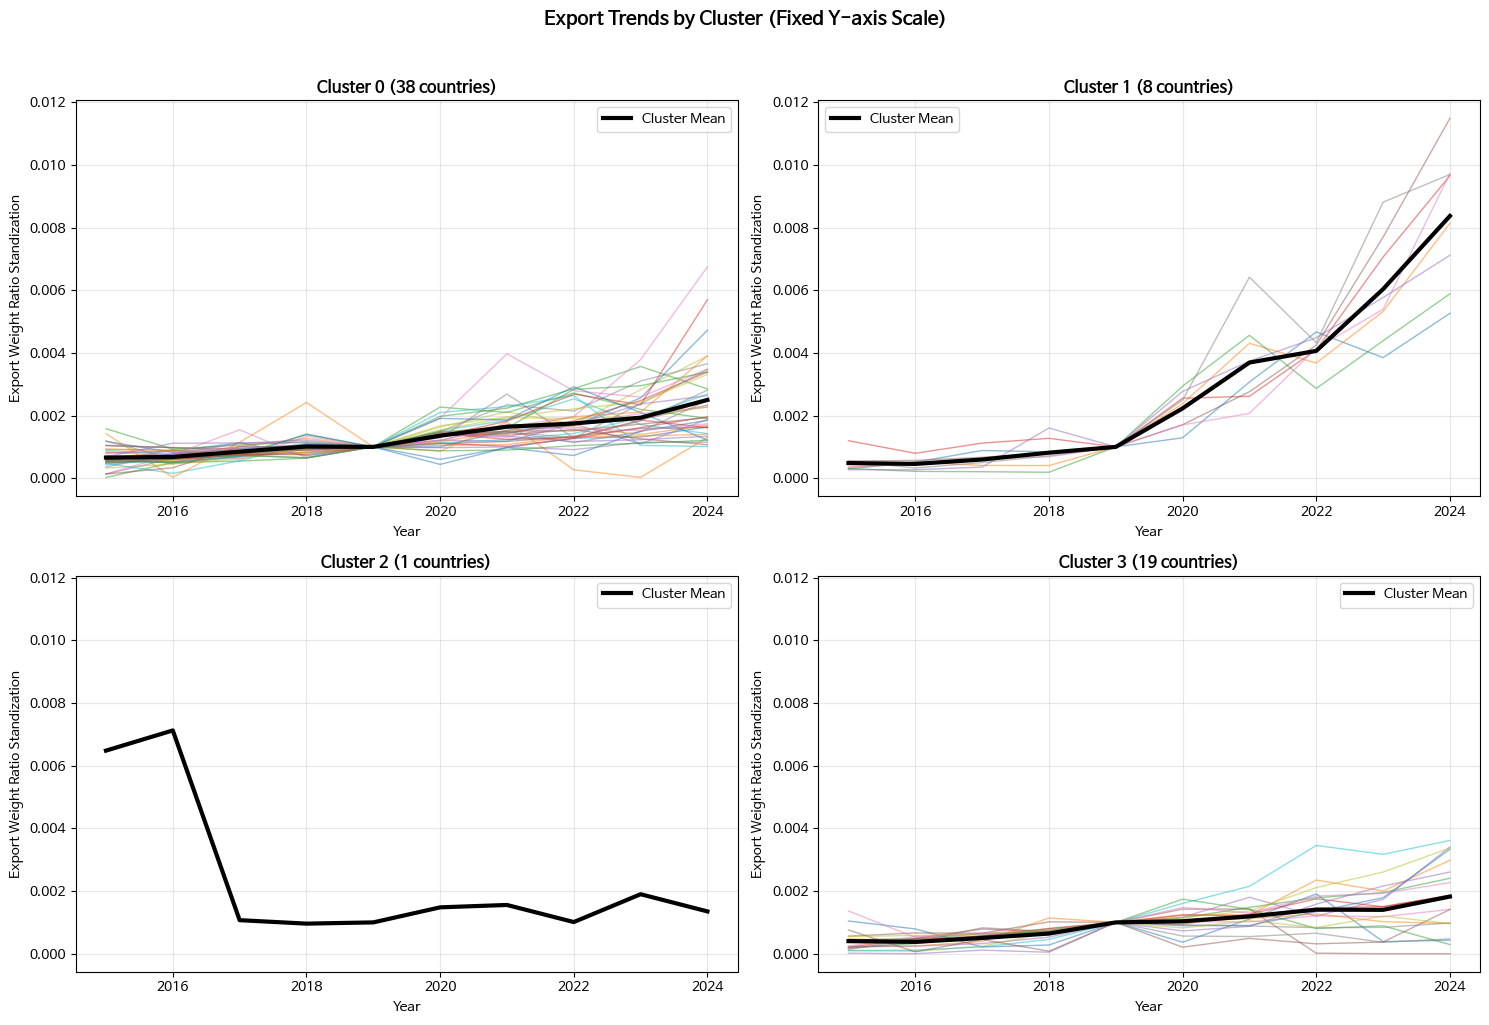

In [ ]:
# ============================================================
# 4. CLUSTER ANALYSIS
# ============================================================

print("\n" + "="*80)
print("CLUSTER CHARACTERISTICS")
print("="*80)

#for cluster_id in range(optimal_k):
for cluster_id in range(4):

    cluster_mask = df_transposed['cluster'] == cluster_id
    cluster_countries = df_transposed[cluster_mask]['statCdCntnKor1'].values
    cluster_data = X[cluster_mask]

    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id} ({len(cluster_countries)} countries)")
    print(f"{'='*60}")
    print(f"Countries: {', '.join(cluster_countries[:10])}")
    if len(cluster_countries) > 10:
        print(f"          ... and {len(cluster_countries)-10} more")

    print(f"\nStatistics (in tons):")
    print(f"  Average 2024 export: {cluster_data[:, -1].mean():,.0f}")
    print(f"  Total 2024 export: {cluster_data[:, -1].sum():,.0f}")
    print(f"  Average growth (2015-2024): {((cluster_data[:, -1].mean() / (cluster_data[:, 0].mean() + 1e-10)) - 1) * 100:.1f}%")

# ============================================================
# 6. TIME SERIES VISUALIZATION BY CLUSTER
# ============================================================

# Plot time series for each cluster
fig, axes = plt.subplots(2, (optimal_k + 1) // 2, figsize=(15, 10))
#fig, axes = plt.subplots(2, (4 + 1) // 2, figsize=(15, 10))
axes = axes.flatten()

years = list(range(2015, 2025))

# Calculate global min and max for Y-axis to ensure all plots have same scale
all_data_in_thousands = X / 1000
global_min = all_data_in_thousands.min()
global_max = all_data_in_thousands.max()

# Add some padding (5% on each side) for better visualization
y_padding = (global_max - global_min) * 0.05
y_min = global_min - y_padding
y_max = global_max + y_padding

print(f"Y-axis range fixed to: [{y_min:.1f}, {y_max:.1f}] (1000 tons)")

#for cluster_id in range(optimal_k):
for cluster_id in range(4):
    ax = axes[cluster_id]
    cluster_mask = df_transposed['cluster'] == cluster_id
    cluster_data = X[cluster_mask]

    # Plot each country in the cluster
    for i, country_data in enumerate(cluster_data):
        ax.plot(years, country_data / 1000, alpha=0.5, linewidth=1)

    # Plot cluster mean
    cluster_mean = cluster_data.mean(axis=0) / 1000
    ax.plot(years, cluster_mean, 'k-', linewidth=3, label='Cluster Mean')

    ax.set_title(f'Cluster {cluster_id} ({sum(cluster_mask)} countries)', fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Export Weight Ratio Standization')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Set the same Y-axis limits for all subplots
    ax.set_ylim(y_min, y_max)

# Remove extra subplots if odd number of clusters
#for i in range(optimal_k, len(axes)):
for i in range(4, len(axes)):

    fig.delaxes(axes[i])

plt.suptitle('Export Trends by Cluster (Fixed Y-axis Scale)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()